##### Neural Network with Pytorch

Goal : Classify two colors 

In [137]:
# Make classification Data
import sklearn
from sklearn.datasets import make_circles

# Make 1000 samples

n_samples = 1000

# Create circles

X , y = make_circles(n_samples,
                     noise = 0.03, 
                     random_state=42)

len(X), len(y)

print(f' First 5 samples X\n : {X[:5]}')
print(f' First 5 samples y\n : {y[:5]}')


 First 5 samples X
 : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
 First 5 samples y
 : [1 1 1 1 0]


In [138]:
# Make DataFrame of circle data
import pandas as pd 
circles = pd.DataFrame({"X1" : X[:,0],
                        "X2" : X[:,1],
                        "label" : y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


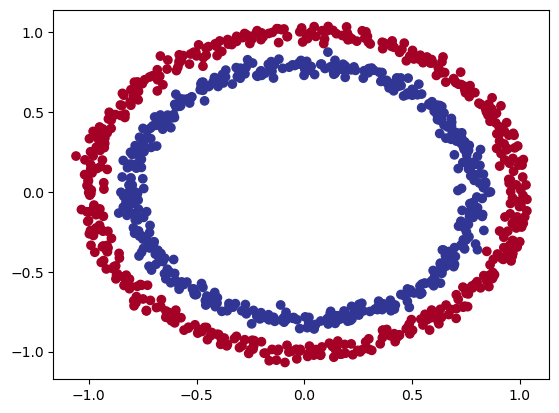

In [139]:
# Visualize results
import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu)

#### 1.1 Check input and output shapes

In [140]:
X.shape , y.shape, X

((1000, 2),
 (1000,),
 array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]))

In [141]:
# View first examples of features and labels

X_sample = X[0]
y_sample = y[0]

print(f' Values for one sample of X : {X_sample} and the same for y : {y_sample}')
print(f' Shapes for one sample of X : {X_sample.shape} and for y: {y_sample.shape}')

 Values for one sample of X : [0.75424625 0.23148074] and the same for y : 1
 Shapes for one sample of X : (2,) and for y: ()


In [142]:
# 1.2 Turn Data into tensors and create train and test splits

import torch 

X = torch.from_numpy(X).type(torch.float) #change data into torch float32 
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5] #Transfor data into tensors 

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [143]:
# Split data into traning and test sets 

from sklearn.model_selection import train_test_split 

X_train , X_test, y_train, y_test = train_test_split(X, #it must have this order according to the documentation
                                                     y, 
                                                     test_size=0.2,  #20% Data to be test and 80% to be trained
                                                     random_state=42)


In [144]:
# 2. building a model

# 2.1 Setup mode

from torch import nn 

# Make device agnostic code 

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [145]:
X_train.shape #in_features = 2

torch.Size([800, 2])

In [146]:
# 2.2 Construct a model using nn.Module 

# 2.2.1 Construct a model nn.Module
class CircleModelV0 (nn.Module): 
    def __init__(self):
        super().__init__()
        
        # 2.2.2 Create 2 nn.Linear layers to handle the shape of the data
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # Change this number ! Takes 2 features and upsclaes to 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # in-fetaures = out_features layer1. Output_feature = y 
        
        #Adding the thing under
        #self.two_linear_layers = nn.Sequential(
         #   nn.Linear(in_features=2, out_features= 5),
          #  nn.Linear(in_features=5, out_features=1)
           # ).to(device)

        
    # 2.2.3 Define Forward () 
    def forward (self, x): 
        return self.layer_2(self.layer_1(x)) # x-> layer_1 -> layer_2 -> output
        #return two_linear_layers (x)

# 2.2.4 Instantiate an instance of out model class and send it to the target device 
model_0 = CircleModelV0().to(device)
model_0
      

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [147]:
# To replicate the model above, bcs it only has 2 layers, we can use nn.Sequential()

model_0 = torch.nn.Sequential(
    nn.Linear(in_features=2, out_features= 5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0


Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [148]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [149]:
# Make predictions 
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f'Lenght of Predictions : {len(untrained_preds)}, Shape : {untrained_preds.shape}')
print(f'Lenght of test Samples: {len(X_test)} , Shape : {X_test.shape}')
print(f' \n First 10 predictions : \n {torch.round(untrained_preds[:10])}')
print(f'\n First 10 labels : \n {y_test[:10]}')

Lenght of Predictions : 200, Shape : torch.Size([200, 1])
Lenght of test Samples: 200 , Shape : torch.Size([200, 2])
 
 First 10 predictions : 
 tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]])

 First 10 labels : 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [150]:
y_test[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

##### 2.1 Setup loss function and optimizer


For classification we use binatry and cross entropy 

For optimizers are SGD and ADAM.



In [151]:

# Setup loss function
#loss_fn = nn.BCELoss() #requieres the sigmoid activation function 

loss_fn = nn.BCEWithLogitsLoss() #

optimizer = torch.optim.SGD (params=model_0.parameters(),
                             lr = 0.1)

# Calculate accuracy - 

def accuracy_fn (y_true, y_pred): 
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred))* 100
    return acc 


#### 3. Train Model 

In [152]:
'''

3.1 From raw logits -> prediction probablitites -> prediction labels

Raw logits are the outputs from the model 

Convert logits into prediction probabilities with sigmoid for binary classification 
and softmax for multiclass classification 

'''

# View 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]])

For our prediction prob values, we need to perform a range-style rounding on them: 
* y_preds_probs >= 0.5, y=1 (class 1)
* y_preds_probs <= 0.5, y=0 (class 0)

In [153]:
y_test[:5] #not the same format as y_logits

# Use sigmoid activation fn on our model logits 
y_pred_prob = torch.sigmoid(y_logits)
y_pred_prob #same format. Now can manipulate them 

torch.round(y_pred_prob)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]])

In [154]:
# Find the predicted labels

y_preds = torch.round(y_pred_prob)

# In full; logits -> pred probs -> pred labels

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check equallity 
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid extra dimensions
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 1.])

In [155]:
y_test[:5] 

tensor([1., 0., 1., 0., 1.])

#### 3.2 Building a test and train loop 

In [162]:
torch.manual_seed(42)

# Epochs

epochs = 1000 

# Target device

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# BUilding training and evaluation loop 

for epoch in range(epochs): 
    
    #Training
    model_0.train()
    
    # 1. Forward pass
    y_logits =model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    # 2. Calculate loss/accuracy
    #loss = loss_fn (torch.sigmoid(y_logits), #nn.BCELoss expects prediction prob as input
     #               y_train)
    loss = loss_fn(y_logits, #expects raw logits as inputs
                   y_train, 
                   )
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)



    # 3. Optimizer
    optimizer.zero_grad ()
    
    # 4. loss backward
    loss.backward()
    
    # 5. Optimizer step
    optimizer.step()
    
    #testing
    model_0.eval()
    with torch.inference_mode(): 
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        # 2. Calculate loss
        test_loss = loss_fn (
            test_logits,
            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred= test_pred)
        
    # Print result
    if epoch % 10 == 0: 
        print(f' epoch : {epoch} , loss : {loss:.5f}, Acc: {acc:.2f}, test loss : {test_loss:.5f}, test acc : {test_acc:.5f}')




 epoch : 0 , loss : 0.69331, Acc: 49.25, test loss : 0.69271, test acc : 53.00000
 epoch : 10 , loss : 0.69327, Acc: 49.75, test loss : 0.69279, test acc : 54.00000
 epoch : 20 , loss : 0.69324, Acc: 50.25, test loss : 0.69286, test acc : 53.00000
 epoch : 30 , loss : 0.69321, Acc: 49.75, test loss : 0.69294, test acc : 55.00000
 epoch : 40 , loss : 0.69319, Acc: 50.62, test loss : 0.69301, test acc : 54.00000
 epoch : 50 , loss : 0.69317, Acc: 52.25, test loss : 0.69307, test acc : 51.00000
 epoch : 60 , loss : 0.69315, Acc: 51.38, test loss : 0.69314, test acc : 56.00000
 epoch : 70 , loss : 0.69314, Acc: 51.12, test loss : 0.69320, test acc : 52.00000
 epoch : 80 , loss : 0.69313, Acc: 51.25, test loss : 0.69325, test acc : 48.50000
 epoch : 90 , loss : 0.69311, Acc: 51.00, test loss : 0.69331, test acc : 50.00000
 epoch : 100 , loss : 0.69310, Acc: 50.88, test loss : 0.69336, test acc : 49.00000
 epoch : 110 , loss : 0.69309, Acc: 50.62, test loss : 0.69341, test acc : 47.50000
 ep

##### 4. Make predictions and visualize them

In [163]:
import requests 

from pathlib import Path 

# Download helper functions 
if Path("helper_functions.py").is_file():
    print("The file does exist")
else: 
    print("Download helper function")
    requests =requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open ("helper_function.py", "wb") as f:
        f.write(requests.content)
        
from helper_function import plot_predictions, plot_decision_boundary
    

Download helper function


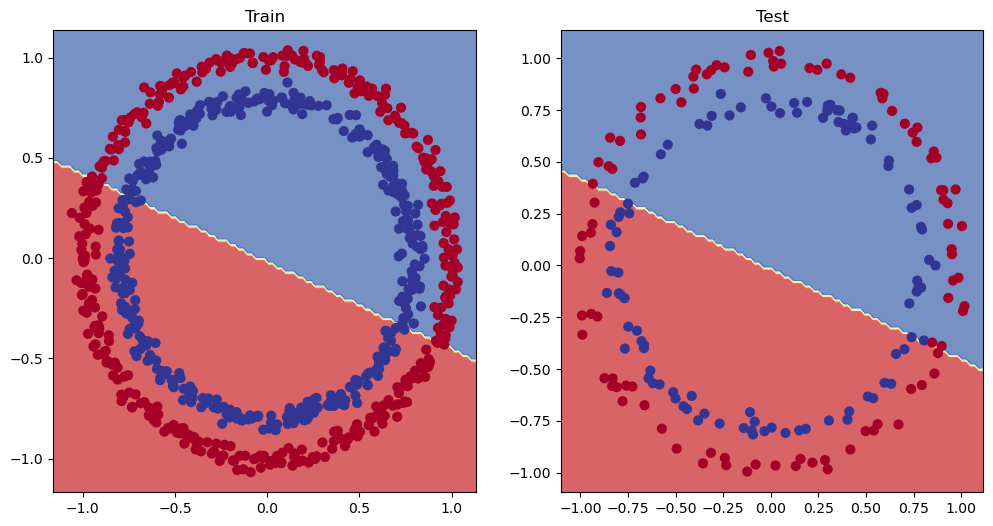

In [164]:
# Plot decision boundary of the model 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

#Testing data
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)